In [33]:
import math
import numpy as np


def geometric_capped(lower, upper, start_width, maximum_width, increase_ratio):

    faces = [float(lower)]
    width = float(start_width)

    while faces[-1] < upper:
        next_face = faces[-1] + width

        faces.append(next_face)
        if width >= maximum_width / increase_ratio :
            width = maximum_width
        else:
            width = width * increase_ratio

    return np.asarray(faces)

In [28]:
f = geometric_capped(0, 200, 0.05, 1.0, 1.03)
df = np.diff(f)
print(len(f))
ind = np.where(df == 1)
print(f[ind[0][0]])
df

271
32.315077780817376


array([0.05      , 0.0515    , 0.053045  , 0.05463635, 0.05627544,
       0.0579637 , 0.05970261, 0.06149369, 0.0633385 , 0.06523866,
       0.06719582, 0.06921169, 0.07128804, 0.07342669, 0.07562949,
       0.07789837, 0.08023532, 0.08264238, 0.08512165, 0.0876753 ,
       0.09030556, 0.09301473, 0.09580517, 0.09867933, 0.10163971,
       0.1046889 , 0.10782956, 0.11106445, 0.11439638, 0.11782828,
       0.12136312, 0.12500402, 0.12875414, 0.13261676, 0.13659526,
       0.14069312, 0.14491392, 0.14926133, 0.15373917, 0.15835135,
       0.16310189, 0.16799495, 0.17303479, 0.17822584, 0.18357261,
       0.18907979, 0.19475219, 0.20059475, 0.20661259, 0.21281097,
       0.2191953 , 0.22577116, 0.23254429, 0.23952062, 0.24670624,
       0.25410743, 0.26173065, 0.26958257, 0.27767005, 0.28600015,
       0.29458016, 0.30341756, 0.31252009, 0.32189569, 0.33155256,
       0.34149914, 0.35174411, 0.36229643, 0.37316533, 0.38436029,
       0.3958911 , 0.40776783, 0.42000086, 0.43260089, 0.44557

In [31]:
f = geometric_capped(0, 200, 0.01, 1.0, 1.03)
df = np.diff(f)
print(len(f))
ind = np.where(df == 1)
print(f[ind[0][0]])
f[185:188]

324
33.20070058623103


array([62.20070059, 63.20070059, 64.20070059])

In [38]:
from astropy import constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML


NT = 1000
Rf = geometric_capped(0, 200, 0.05, 1.0, 1.03)
Zf = geometric_capped(0, 200, 0.01, 1.0, 1.03)
NR = len(Rf) + 4
NZ = len(Zf) + 4
Rc = (Rf[1:] + Rf[:-1]) /2
Zc = (Zf[1:] + Zf[:-1]) /2
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
t = np.arange(NT)*1e5
c_lst = ["red", "blue", "orange", "green", "purple", "yellow", "cyan", "magenta", "black", "pink", "lime"]
def numerical_diffusion(ndis):
    N_tot = np.sum(ndis * dV[None,:], axis = (1,2))
    mc_R = np.sum(ndis * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
    mc_Z = np.sum(ndis * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot
    
    sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis*dV[None,:,:],axis=(1,2))/N_tot
    D_R = (sigma_R[1:] - sigma_R[0]) / 2 / (t[1:] - t[0])
    D_Z = (sigma_Z[1:] - sigma_Z[0]) / 2 / (t[1:] - t[0]) 

    return N_tot, mc_R, mc_Z, sigma_R, sigma_Z, cov, D_R, D_Z


In [34]:
ls *dR50*

ndis_C_transport_dR50_dz10_r1.03_dt1e4_MC.bin


In [39]:
ndis_C = np.fromfile("ndis_C_transport_dR50_dz10_r1.03_dt1e4_MC_fix.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)
ndis_C = ndis_C[:,2:-2,2:-2]
fig, ax = plt.subplots()

ndis_log = np.log10(ndis_C + 1e-100)
ndis = ax.pcolormesh(Rc, Zc, ndis_log[0].T,shading="auto", vmin = -3, vmax = -1 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale') 

def animate(i):
    ndis.set_array(ndis_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=NT,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

Text(0.5, 1.0, 'D_num')

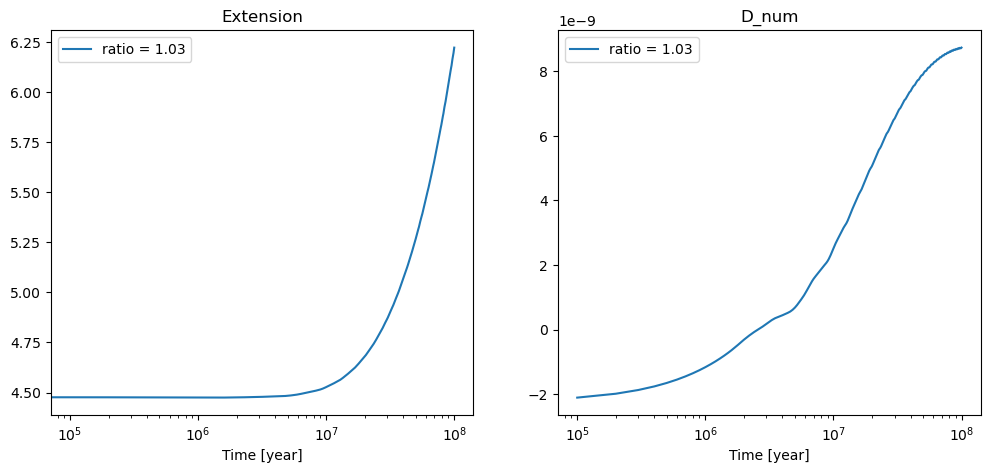

In [37]:
nd = numerical_diffusion(ndis_C)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd[3], label="ratio = 1.03")
axes[0].legend()
axes[0].set_xscale("log")
# axes[0].set_yscale("log")
axes[0].set_xlabel("Time [year]")
axes[0].set_title("Extension")

axes[1].plot(t[1:], nd[6], label="ratio = 1.03")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Time [year]")
axes[1].set_title("D_num")

In [26]:
np.any(np.isnan(ndis_log))

np.True_

In [20]:
ind = np.where(np.diff(Zf) == 1)
Zf[ind[0]][0]

np.float64(33.20070058623103)

In [40]:
NT = 1000
Rf = geometric_capped(0, 200, 0.05, 1.0, 1.02)
Zf = geometric_capped(0, 200, 0.01, 1.0, 1.02)
NR = len(Rf) + 4
NZ = len(Zf) + 4
Rc = (Rf[1:] + Rf[:-1]) /2
Zc = (Zf[1:] + Zf[:-1]) /2
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
t = np.arange(NT)*1e5
c_lst = ["red", "blue", "orange", "green", "purple", "yellow", "cyan", "magenta", "black", "pink", "lime"]
def numerical_diffusion(ndis):
    N_tot = np.sum(ndis * dV[None,:], axis = (1,2))
    mc_R = np.sum(ndis * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
    mc_Z = np.sum(ndis * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot
    
    sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis*dV[None,:,:],axis=(1,2))/N_tot
    D_R = (sigma_R[1:] - sigma_R[0]) / 2 / (t[1:] - t[0])
    D_Z = (sigma_Z[1:] - sigma_Z[0]) / 2 / (t[1:] - t[0]) 

    return N_tot, mc_R, mc_Z, sigma_R, sigma_Z, cov, D_R, D_Z
ndis_C = np.fromfile("ndis_C_transport_dR50_dz10_r1.02_dt1e4_MC.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)
ndis_C = ndis_C[:,2:-2,2:-2]
fig, ax = plt.subplots()

ndis_log = np.log10(ndis_C + 1e-100)
ndis = ax.pcolormesh(Rc, Zc, ndis_log[0].T,shading="auto", vmin = -3, vmax = -1 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale') 

def animate(i):
    ndis.set_array(ndis_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=NT,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

Text(0.5, 1.0, 'D_num')

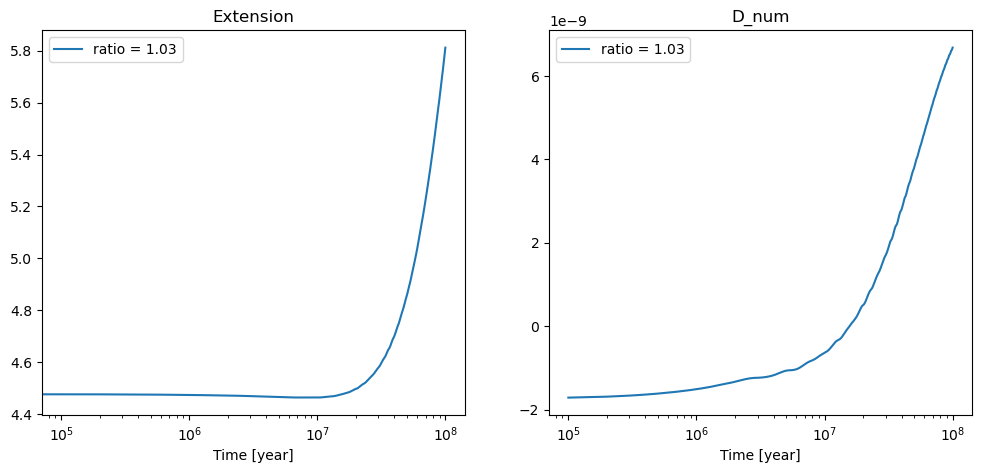

In [41]:
nd = numerical_diffusion(ndis_C)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd[3], label="ratio = 1.03")
axes[0].legend()
axes[0].set_xscale("log")
# axes[0].set_yscale("log")
axes[0].set_xlabel("Time [year]")
axes[0].set_title("Extension")

axes[1].plot(t[1:], nd[6], label="ratio = 1.03")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Time [year]")
axes[1].set_title("D_num")

In [42]:
NT = 1000
Rf = geometric_capped(0, 200, 0.05, 1.0, 1.01)
Zf = geometric_capped(0, 200, 0.01, 1.0, 1.01)
NR = len(Rf) + 4
NZ = len(Zf) + 4
Rc = (Rf[1:] + Rf[:-1]) /2
Zc = (Zf[1:] + Zf[:-1]) /2
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
t = np.arange(NT)*1e5
c_lst = ["red", "blue", "orange", "green", "purple", "yellow", "cyan", "magenta", "black", "pink", "lime"]
def numerical_diffusion(ndis):
    N_tot = np.sum(ndis * dV[None,:], axis = (1,2))
    mc_R = np.sum(ndis * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
    mc_Z = np.sum(ndis * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot
    
    sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis*dV[None,:,:],axis=(1,2))/N_tot
    D_R = (sigma_R[1:] - sigma_R[0]) / 2 / (t[1:] - t[0])
    D_Z = (sigma_Z[1:] - sigma_Z[0]) / 2 / (t[1:] - t[0]) 

    return N_tot, mc_R, mc_Z, sigma_R, sigma_Z, cov, D_R, D_Z
ndis_C = np.fromfile("ndis_C_transport_dR50_dz10_r1.01_dt1e4_MC.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)
ndis_C = ndis_C[:,2:-2,2:-2]
fig, ax = plt.subplots()

ndis_log = np.log10(ndis_C + 1e-100)
ndis = ax.pcolormesh(Rc, Zc, ndis_log[0].T,shading="auto", vmin = -3, vmax = -1 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale') 

def animate(i):
    ndis.set_array(ndis_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=NT,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

Text(0.5, 1.0, 'D_num')

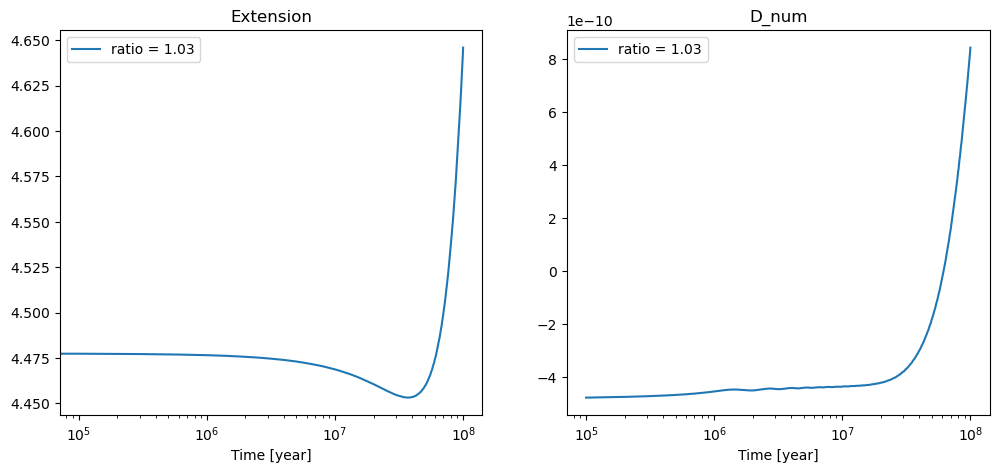

In [43]:
nd = numerical_diffusion(ndis_C)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd[3], label="ratio = 1.03")
axes[0].legend()
axes[0].set_xscale("log")
# axes[0].set_yscale("log")
axes[0].set_xlabel("Time [year]")
axes[0].set_title("Extension")

axes[1].plot(t[1:], nd[6], label="ratio = 1.03")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Time [year]")
axes[1].set_title("D_num")